# Main Experiments for Member 2

**Paper:** *Identifying and Clustering Counter Relationships of Team Compositions in PvP Games for Efficient Balance Analysis*  
**Reproduction scope:** Simple Combination Game from Section 4.1.1  
**Owner:** Member 2 - Core Algorithm Implementer

Notebook này đã được chỉnh để chạy thuận hơn trên **Google Colab**:
- tự dò `project root` thay vì hard-code `..`;
- có cell cấu hình riêng cho số fold, số epoch, `M values`, output prefix;
- tự lưu bảng kết quả và hình vào thư mục `results/` sau khi chạy.

Nếu Colab không tự dò được repo, chỉ cần sửa biến `PROJECT_ROOT_OVERRIDE` ở cell cấu hình.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import json
import sys
import time
from ast import literal_eval
from pathlib import Path

IS_COLAB = 'google.colab' in sys.modules

PROJECT_ROOT_OVERRIDE = '/content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering'

def detect_project_root(override=None):
    if override is not None:
        root = Path(override).expanduser().resolve()
        if not (root / 'Group_11' / 'src').exists():
            raise FileNotFoundError(f'Invalid PROJECT_ROOT_OVERRIDE: {root}')
        return root

    candidates = []
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    candidates.extend([
        Path('/content'),
        Path('/content/DM_Lab03_Clustering'),
        Path('/content/drive/MyDrive'),
        Path('/content/drive/MyDrive/DM_Lab03_Clustering'),
    ])

    seen = set()
    for candidate in candidates:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / 'Group_11' / 'src').exists():
            return candidate

    raise FileNotFoundError(
        'Cannot detect project root automatically. Set PROJECT_ROOT_OVERRIDE first.'
    )

PROJECT_ROOT = detect_project_root(PROJECT_ROOT_OVERRIDE)
GROUP_DIR = PROJECT_ROOT / 'Group_11'
RESULT_DIR = GROUP_DIR / 'results'
DATA_DIR = GROUP_DIR / 'data'
RESULT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

if str(GROUP_DIR) not in sys.path:
    sys.path.append(str(GROUP_DIR))

print('IS_COLAB =', IS_COLAB)
print('PROJECT_ROOT =', PROJECT_ROOT)
print('GROUP_DIR =', GROUP_DIR)
print('RESULT_DIR =', RESULT_DIR)

IS_COLAB = True
PROJECT_ROOT = /content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering
GROUP_DIR = /content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering/Group_11
RESULT_DIR = /content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering/Group_11/results


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.model_selection import KFold

from src.synthetic_data import (
    SimpleCombinationConfig,
    build_feature_matrix,
    save_simple_combination_dataset,
)
from src.model import (
    NeuralCounterTable,
    NeuralRatingTable,
    predict_nct,
    predict_nrt,
    set_random_seed,
    train_nct_fullbatch,
    train_nrt_fullbatch,
)
from src.metrics import (
    attach_pairwin_from_table,
    codebook_utilization,
    pairwin_table,
    relative_deviation,
    strength_relation_accuracy,
    unsupervised_clustering_scores,
)

sns.set_theme(style='whitegrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)

DEVICE = cuda


## 1. Configuration

Nếu cần debug nhanh trên Colab, giảm `NUM_MATCHES`, `NRT_EPOCHS`, `NCT_EPOCHS`, hoặc `M_VALUES`.

In [27]:
OUTPUT_PREFIX = 'member2_cv'
SEED = 42
NUM_MATCHES = 100_000
N_SPLITS = 5
NRT_EPOCHS = 100
NCT_EPOCHS = 100
LEARNING_RATE = 2.5e-4
BETA_N = 0.01
BETA_M = 0.25
M_VALUES = [3, 9, 27, 81]

DATA_PATH = DATA_DIR / 'simple_combination_game.csv'
FIGURE_PATH = RESULT_DIR / f'{OUTPUT_PREFIX}_training_and_accuracy.png'
FOLD_SUMMARY_PATH = RESULT_DIR / f'{OUTPUT_PREFIX}_fold_summary.csv'
AGGREGATE_PATH = RESULT_DIR / f'{OUTPUT_PREFIX}_aggregate.csv'
COMPARISON_PATH = RESULT_DIR / f'{OUTPUT_PREFIX}_comparison.csv'
RESULTS_JSON_PATH = RESULT_DIR / f'{OUTPUT_PREFIX}_results.json'

print('OUTPUT_PREFIX =', OUTPUT_PREFIX)
print('DATA_PATH =', DATA_PATH)

OUTPUT_PREFIX = member2_cv
DATA_PATH = /content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering/Group_11/data/simple_combination_game.csv


## 2. Generate The Dataset From The Paper

Theo Section 4.1.1 của paper:
- có 20 phần tử;
- mỗi composition chứa 3 phần tử khác nhau;
- tổng cộng `C(20, 3) = 1140` compositions;
- sinh `NUM_MATCHES` trận bằng uniform sampling;
- xác suất thắng của composition A là `s_A^2 / (s_A^2 + s_B^2)`.

In [11]:
config = SimpleCombinationConfig(
    num_elements=20,
    team_size=3,
    num_matches=NUM_MATCHES,
    random_state=SEED,
)
df = save_simple_combination_dataset(DATA_PATH, config=config)
print(f'Dataset saved to: {DATA_PATH}')
print(df.shape)
df.head()

Dataset saved to: /content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering/Group_11/data/simple_combination_game.csv
(100000, 13)


,match_id,comp_a,comp_b,a_1,a_2,a_3,b_1,b_2,b_3,score_a,score_b,win_prob_a,label
0,0,"(1, 8, 17)","(7, 14, 20)",1,8,17,7,14,20,26,41,0.286805,1.0
1,1,"(8, 11, 19)","(10, 15, 16)",8,11,19,10,15,16,38,41,0.462080,1.0
2,2,"(6, 12, 19)","(5, 12, 15)",6,12,19,5,12,15,37,32,0.572085,1.0
3,3,"(4, 7, 19)","(4, 5, 18)",4,7,19,4,5,18,30,27,0.552486,1.0
4,4,"(4, 7, 12)","(1, 2, 8)",4,7,12,1,2,8,23,11,0.813846,1.0


## 3. Prepare Features

PairWin ground truth sẽ được tính **riêng bên trong từng fold** để tránh leakage ở evaluation.

In [12]:
parse_comp = lambda value: literal_eval(value) if isinstance(value, str) else value
comp_a_features = build_feature_matrix(df['comp_a'].map(parse_comp), num_elements=config.num_elements)
comp_b_features = build_feature_matrix(df['comp_b'].map(parse_comp), num_elements=config.num_elements)
labels = df['label'].to_numpy(dtype=np.float32)
indices = np.arange(len(df))

print('Samples:', len(df))
print('Feature dim:', comp_a_features.shape[1])

Samples: 100000
Feature dim: 20


## 4. 5-Fold Cross-Validation With Clean PairWin Labels

Trong mỗi fold:
- tạo train/test split bằng `KFold`;
- tính PairWin riêng cho train và test;
- augment train bằng swap `(A, B) -> (B, A)`;
- train `NRT`;
- train `NCT` với `M in M_VALUES`.

In [13]:
set_random_seed(SEED)
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_runs = []
run_start = time.time()

for fold_id, (train_idx, test_idx) in enumerate(kf.split(indices), start=1):
    fold_start = time.time()
    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    train_pairwin_lookup = pairwin_table(train_df)
    test_pairwin_lookup = pairwin_table(test_df)
    train_df = attach_pairwin_from_table(train_df, train_pairwin_lookup)
    test_df = attach_pairwin_from_table(test_df, test_pairwin_lookup)

    train_a = comp_a_features[train_idx]
    train_b = comp_b_features[train_idx]
    train_y = train_df['label'].to_numpy(dtype=np.float32)

    aug_a = np.concatenate([train_a, train_b], axis=0)
    aug_b = np.concatenate([train_b, train_a], axis=0)
    aug_y = np.concatenate([train_y, 1.0 - train_y], axis=0)

    test_a = comp_a_features[test_idx]
    test_b = comp_b_features[test_idx]
    test_pairwin = test_df['pairwin_value'].to_numpy(dtype=np.float32)

    set_random_seed(SEED + fold_id)
    nrt_model = NeuralRatingTable(input_dim=config.num_elements)
    nrt_history = train_nrt_fullbatch(
        nrt_model,
        aug_a,
        aug_b,
        aug_y,
        epochs=NRT_EPOCHS,
        learning_rate=LEARNING_RATE,
        device=DEVICE,
    )
    nrt_pred = predict_nrt(nrt_model, test_a, test_b, device=DEVICE)
    nrt_acc = strength_relation_accuracy(nrt_pred, test_pairwin)

    fold_record = {
        'fold': fold_id,
        'nrt_accuracy': nrt_acc,
        'nrt_history': nrt_history,
        'nct_results': {},
    }

    for m_value in M_VALUES:
        set_random_seed(SEED + fold_id * 100 + m_value)
        nct_model = NeuralCounterTable(
            input_dim=config.num_elements,
            num_embeddings=m_value,
            embedding_dim=128,
            hidden_dim=128,
        )
        nct_history = train_nct_fullbatch(
            nct_model,
            nrt_model,
            aug_a,
            aug_b,
            aug_y,
            epochs=NCT_EPOCHS,
            learning_rate=LEARNING_RATE,
            beta_n=BETA_N,
            beta_m=BETA_M,
            device=DEVICE,
        )
        nct_outputs = predict_nct(nrt_model, nct_model, test_a, test_b, device=DEVICE)
        nct_acc = strength_relation_accuracy(nct_outputs['win_value'], test_pairwin)
        clustering = unsupervised_clustering_scores(nct_outputs['latent_a'], nct_outputs['category_a'])
        utilization = codebook_utilization(nct_outputs['category_a'], num_embeddings=m_value)

        fold_record['nct_results'][m_value] = {
            'accuracy': nct_acc,
            'clustering': clustering,
            'utilization': utilization,
            'history': nct_history,
        }

    fold_runs.append(fold_record)
    print(f'Finished fold {fold_id}/{N_SPLITS} in {time.time() - fold_start:.1f}s')

print(f'Total runtime: {time.time() - run_start:.1f}s')

Finished fold 1/5 in 67.0s
Finished fold 2/5 in 72.2s
Finished fold 3/5 in 66.3s
Finished fold 4/5 in 65.9s
Finished fold 5/5 in 60.4s
Total runtime: 331.7s


## 5. Fold-Level Results

In [16]:
records = []
for fold_run in fold_runs:
    records.append({
        'fold': fold_run['fold'],
        'method': 'NRT',
        'accuracy': fold_run['nrt_accuracy'],
        'silhouette_score': np.nan,
        'davies_bouldin_index': np.nan,
        'calinski_harabasz_index': np.nan,
        'used_codes': np.nan,
        'utilization_ratio': np.nan,
    })
    for m_value, result in fold_run['nct_results'].items():
        records.append({
            'fold': fold_run['fold'],
            'method': f'NCT (M={m_value})',
            'accuracy': result['accuracy'],
            'silhouette_score': result['clustering']['silhouette_score'],
            'davies_bouldin_index': result['clustering']['davies_bouldin_index'],
            'calinski_harabasz_index': result['clustering']['calinski_harabasz_index'],
            'used_codes': result['utilization']['used_codes'],
            'utilization_ratio': result['utilization']['utilization_ratio'],
        })
fold_summary = pd.DataFrame(records)
fold_summary

,fold,method,accuracy,silhouette_score,davies_bouldin_index,calinski_harabasz_index,used_codes,utilization_ratio
0,1,NRT,0.64975,NaN,NaN,NaN,NaN,NaN
1,1,NCT (M=3),0.64975,NaN,NaN,NaN,1.0,0.333333
2,1,NCT (M=9),0.65020,0.550316,0.611895,40827.472656,2.0,0.222222
3,1,NCT (M=27),0.65175,0.062688,0.810221,12227.498047,4.0,0.148148
4,1,NCT (M=81),0.65350,0.198030,1.038852,19645.378906,4.0,0.049383
5,2,NRT,0.65625,NaN,NaN,NaN,NaN,NaN
6,2,NCT (M=3),0.65590,0.388595,0.517152,5917.612793,2.0,0.666667
7,2,NCT (M=9),0.65625,0.263470,0.535407,2126.182373,2.0,0.222222
8,2,NCT (M=27),0.65495,0.303454,0.770253,29194.525391,3.0,0.111111
9,2,NCT (M=81),0.65630,0.264368,0.686589,24941.230469,3.0,0.037037


## 6. Aggregated Results

In [17]:
aggregate = (
    fold_summary.groupby('method', as_index=False)
    .agg(
        accuracy_mean=('accuracy', 'mean'),
        accuracy_std=('accuracy', 'std'),
        silhouette_mean=('silhouette_score', 'mean'),
        dbi_mean=('davies_bouldin_index', 'mean'),
        chi_mean=('calinski_harabasz_index', 'mean'),
        used_codes_mean=('used_codes', 'mean'),
        utilization_mean=('utilization_ratio', 'mean'),
    )
)
aggregate

,method,accuracy_mean,accuracy_std,silhouette_mean,dbi_mean,chi_mean,used_codes_mean,utilization_mean
0,NCT (M=27),0.65554,0.003063,0.244502,0.784574,22674.379688,3.0,0.111111
1,NCT (M=3),0.65532,0.003421,0.388595,0.517152,5917.612793,1.2,0.400000
2,NCT (M=81),0.65603,0.002516,0.177127,1.020153,18302.158203,4.0,0.049383
3,NCT (M=9),0.65479,0.003284,0.446678,0.588919,25415.345886,1.8,0.200000
4,NRT,0.65539,0.003440,NaN,NaN,NaN,NaN,NaN


## 7. Comparison Against Table 2 Of The Paper

Testing accuracies for `Simple Combination Game` in Table 2:
- `NRT = 64.9%`
- `NCT M=3 = 64.4%`
- `NCT M=9 = 64.2%`
- `NCT M=27 = 64.2%`
- `NCT M=81 = 63.9%`

In [18]:
paper_reference = pd.DataFrame([
    {'method': 'NRT', 'paper_accuracy': 0.649},
    {'method': 'NCT (M=3)', 'paper_accuracy': 0.644},
    {'method': 'NCT (M=9)', 'paper_accuracy': 0.642},
    {'method': 'NCT (M=27)', 'paper_accuracy': 0.642},
    {'method': 'NCT (M=81)', 'paper_accuracy': 0.639},
])

comparison = paper_reference.merge(
    aggregate[['method', 'accuracy_mean']],
    on='method',
    how='left',
)
comparison['relative_deviation'] = comparison.apply(
    lambda row: relative_deviation(row['accuracy_mean'], row['paper_accuracy']),
    axis=1,
)
comparison

,method,paper_accuracy,accuracy_mean,relative_deviation
0,NRT,0.649,0.65539,0.009846
1,NCT (M=3),0.644,0.65532,0.017578
2,NCT (M=9),0.642,0.65479,0.019922
3,NCT (M=27),0.642,0.65554,0.021090
4,NCT (M=81),0.639,0.65603,0.026651


## 8. Save Results To results/

In [28]:
fold_summary.to_csv(FOLD_SUMMARY_PATH, index=False)
aggregate.to_csv(AGGREGATE_PATH, index=False)
comparison.to_csv(COMPARISON_PATH, index=False)

RESULTS_JSON_PATH.write_text(
    json.dumps(
        {
            'config': {
                'seed': SEED,
                'num_matches': NUM_MATCHES,
                'n_splits': N_SPLITS,
                'nrt_epochs': NRT_EPOCHS,
                'nct_epochs': NCT_EPOCHS,
                'learning_rate': LEARNING_RATE,
                'beta_n': BETA_N,
                'beta_m': BETA_M,
                'm_values': M_VALUES,
            },
            'fold_summary': fold_summary.to_dict(orient='records'),
            'aggregate': aggregate.to_dict(orient='records'),
            'comparison': comparison.to_dict(orient='records'),
        },
        indent=2,
    ),
    encoding='utf-8',
)

print('Saved:')
print('-', FOLD_SUMMARY_PATH)
print('-', AGGREGATE_PATH)
print('-', COMPARISON_PATH)
print('-', RESULTS_JSON_PATH)

Saved:
- /content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering/Group_11/results/member2_cv_fold_summary.csv
- /content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering/Group_11/results/member2_cv_aggregate.csv
- /content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering/Group_11/results/member2_cv_comparison.csv
- /content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering/Group_11/results/member2_cv_results.json


## 9. Visualizations

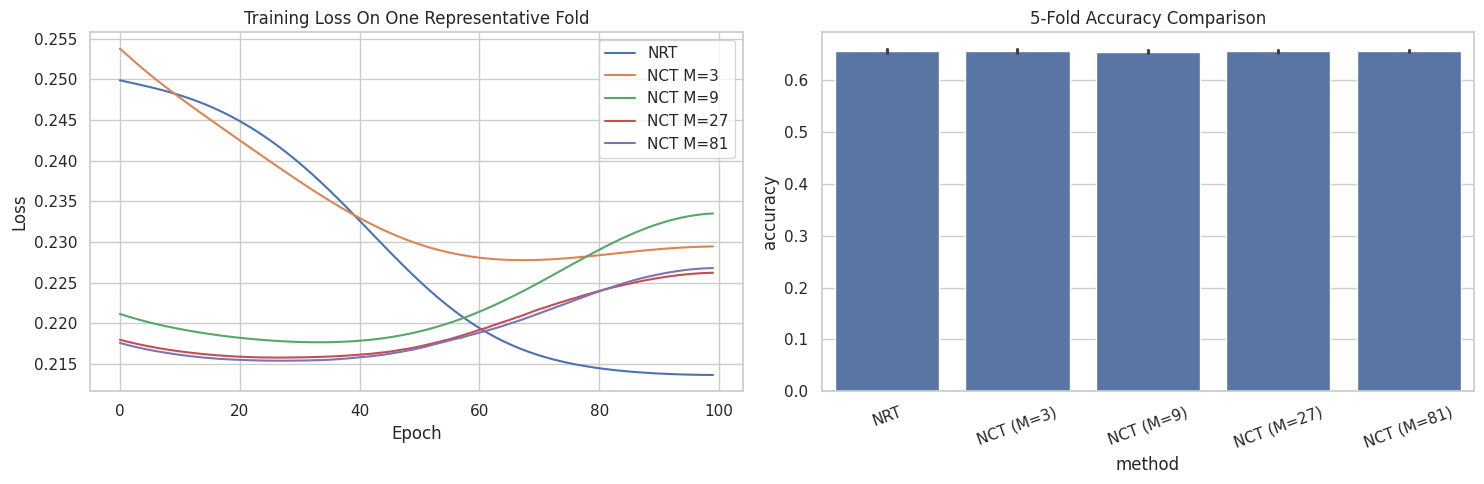

In [29]:
best_m = max(M_VALUES)
best_fold = max(fold_runs, key=lambda item: item['nct_results'][best_m]['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(best_fold['nrt_history'].total_loss, label='NRT')
for m_value in M_VALUES:
    axes[0].plot(best_fold['nct_results'][m_value]['history'].total_loss, label=f'NCT M={m_value}')
axes[0].set_title('Training Loss On One Representative Fold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

sns.barplot(data=fold_summary, x='method', y='accuracy', ax=axes[1], errorbar='sd')
axes[1].set_title('5-Fold Accuracy Comparison')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 10. Notes

Notebook này ưu tiên tính đúng đắn đánh giá hơn tốc độ:
- PairWin ground truth được tính riêng theo từng fold;
- kết quả chính dùng 5-fold CV;
- NCT được sweep theo nhiều giá trị `M` để đối chiếu trực tiếp với Table 2;
- toàn bộ output được lưu vào `results/`, phù hợp để chạy trên Colab rồi tải kết quả về.